# Shape toroidal AutoEncoder
latent space $\mathbb{R}^D / {A\mathbb{Z}^D$ with $A$ learnable

In [13]:
import os
import sys

mvae_dir = os.path.split(os.getcwd())[0]
if mvae_dir not in sys.path:
    sys.path.append(mvae_dir)

In [14]:
%pwd
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Imports

In [15]:
import torch
import numpy as np
import torch.optim as optim

import lib.dataloaders as dataloaders
import lib.models as models
from lib.trainer import AETrainer
import lib.utils as utils



### Set up and initialize data loader

In [16]:
# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

### Dataloader

In [17]:
A = torch.tensor([[1.0, 0.0], [0.0, 1.0]])  # Example A
# embed_dim = 10
#A = torch.tensor([[1.0]])  # Example A
embed_dim = 10
translation = torch.rand(embed_dim) *100
#translation = torch.tensor([0])

batch_size = 64

_, pointcloud, pointcloud_embedded = dataloaders.generate_toroidal_pointcloud(A=A, embed_dim=embed_dim, num_points=20000, translation=translation)
dataloader = dataloaders.load_shaped_torus(pointcloud_embedded,batch_size)

pointcloud translated


### Model

In [18]:
data_dim = embed_dim
hidden_dim1 = 8
hidden_dim2 = 4
latent_dim = 2
activation = torch.nn.ReLU

shape_model = models.ShapeToroidalAE(data_dim=data_dim, hidden_dim1=hidden_dim1, hidden_dim2=hidden_dim2, latent_dim=latent_dim, activation=activation)
euclidean_model = models.EuclideanAE(data_dim=data_dim, hidden_dim1=hidden_dim1, hidden_dim2=hidden_dim2, latent_dim=2*latent_dim)

### Optimizer

In [19]:
learning_rate = 0.001

shape_optimizer = optim.Adam(shape_model.parameters(), lr=learning_rate)
euclidean_optimizer = optim.Adam(euclidean_model.parameters(), lr=learning_rate)

### Trainer setup

In [20]:
num_epochs = 30
log_interval = 100
device = "cpu"
dataset = "synthetic"

trainer_config = {'num_epochs': num_epochs, 'log_interval': log_interval, 'device': device, 'dataset': dataset }

train_loader, test_loader = dataloader


### Train and evaluate shape model

Trainer successfully initialized.
Start training...
Epoch 0
Step [100/282], Loss: 4767.0732, Shape matrix A:1, A_inv_T:1
Step [200/282], Loss: 4682.6416, Shape matrix A:1, A_inv_T:1


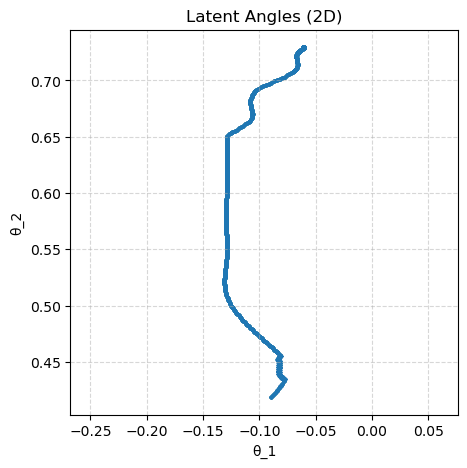

Epoch 1/30, Train Loss: 4713.4113, Test Loss: 4512.6823
Epoch 1
Step [100/282], Loss: 4225.4346, Shape matrix A:1, A_inv_T:1
Step [200/282], Loss: 3863.2664, Shape matrix A:1, A_inv_T:1


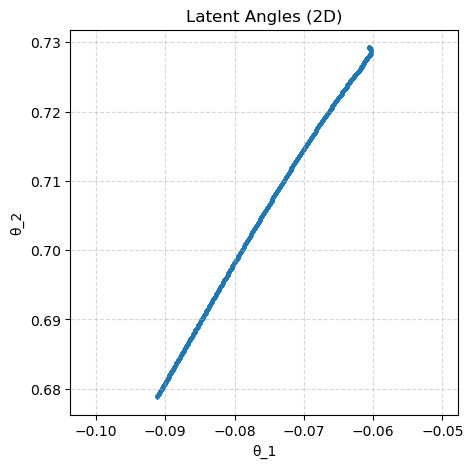

Epoch 2/30, Train Loss: 4060.3214, Test Loss: 3524.9379
Epoch 2
Step [100/282], Loss: 3101.0298, Shape matrix A:1, A_inv_T:1
Step [200/282], Loss: 2666.5254, Shape matrix A:1, A_inv_T:1


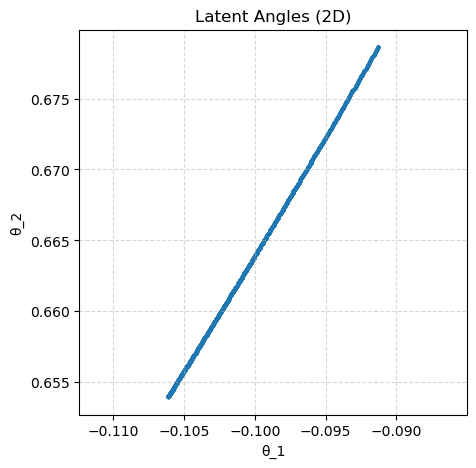

Epoch 3/30, Train Loss: 2920.4585, Test Loss: 2317.0142
Epoch 3
Step [100/282], Loss: 1922.4955, Shape matrix A:1, A_inv_T:1
Step [200/282], Loss: 1561.4027, Shape matrix A:1, A_inv_T:1


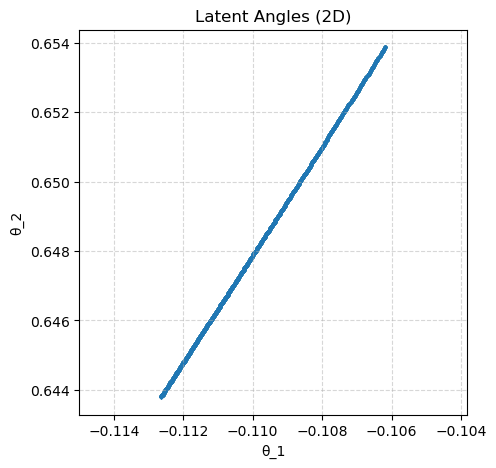

Epoch 4/30, Train Loss: 1781.7249, Test Loss: 1294.2881
Epoch 4
Step [100/282], Loss: 1016.5961, Shape matrix A:1, A_inv_T:1
Step [200/282], Loss: 779.4183, Shape matrix A:1, A_inv_T:1


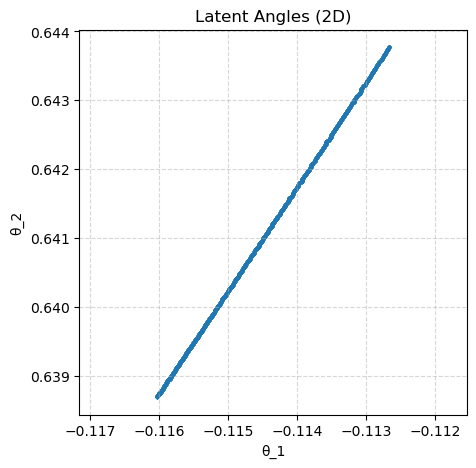

Epoch 5/30, Train Loss: 925.0741, Test Loss: 611.9009
Epoch 5
Step [100/282], Loss: 451.8983, Shape matrix A:1, A_inv_T:1
Step [200/282], Loss: 322.8149, Shape matrix A:1, A_inv_T:1


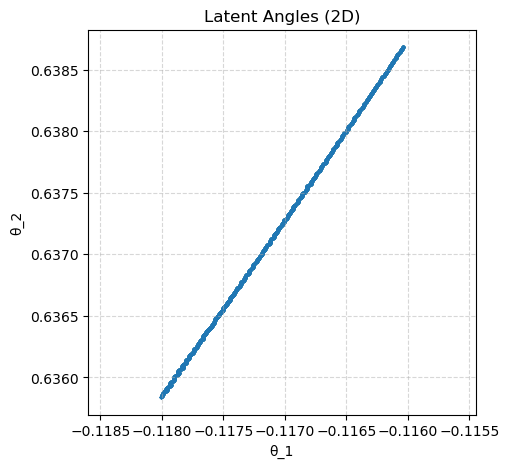

Epoch 6/30, Train Loss: 404.7883, Test Loss: 240.6664
Epoch 6
Step [100/282], Loss: 166.4328, Shape matrix A:1, A_inv_T:1
Step [200/282], Loss: 111.7814, Shape matrix A:1, A_inv_T:1


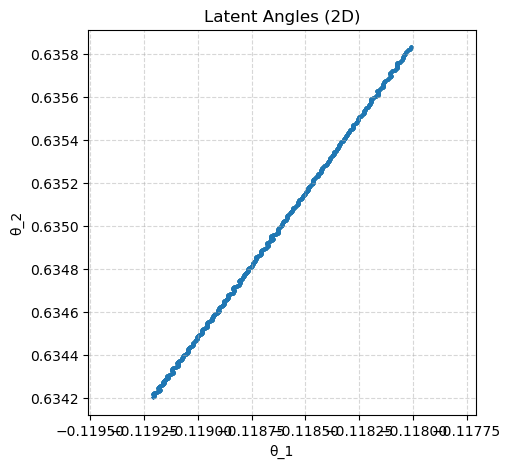

Epoch 7/30, Train Loss: 146.9395, Test Loss: 78.1843
Epoch 7
Step [100/282], Loss: 50.5386, Shape matrix A:1, A_inv_T:1
Step [200/282], Loss: 32.2996, Shape matrix A:1, A_inv_T:1


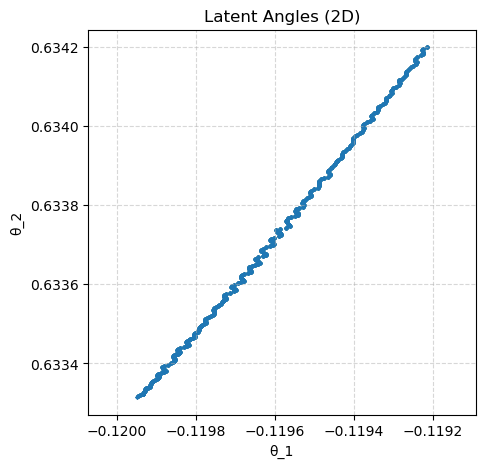

Epoch 8/30, Train Loss: 44.6039, Test Loss: 21.6831
Epoch 8
Step [100/282], Loss: 13.2420, Shape matrix A:1, A_inv_T:1
Step [200/282], Loss: 8.5046, Shape matrix A:1, A_inv_T:1


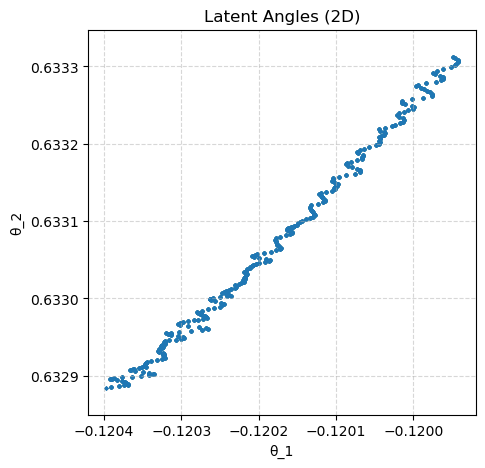

Epoch 9/30, Train Loss: 11.8669, Test Loss: 5.5019
Epoch 9
Step [100/282], Loss: 3.4446, Shape matrix A:1, A_inv_T:1
Step [200/282], Loss: 2.0361, Shape matrix A:1, A_inv_T:1


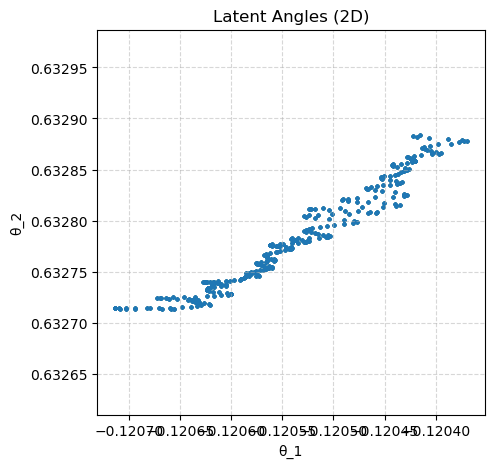

Epoch 10/30, Train Loss: 2.9987, Test Loss: 1.4179
Epoch 10
Step [100/282], Loss: 0.9214, Shape matrix A:1, A_inv_T:1
Step [200/282], Loss: 0.6076, Shape matrix A:1, A_inv_T:1


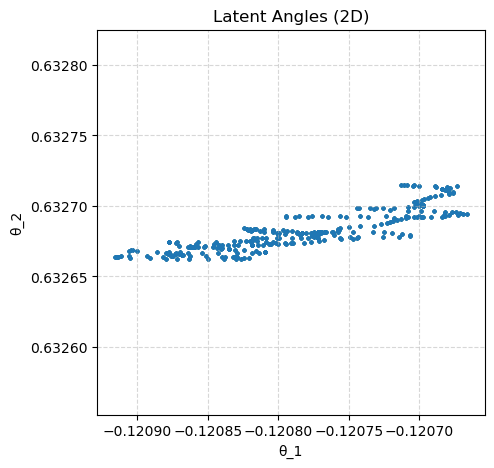

Epoch 11/30, Train Loss: 0.8258, Test Loss: 0.4569
Epoch 11
Step [100/282], Loss: 0.3555, Shape matrix A:1, A_inv_T:1
Step [200/282], Loss: 0.2681, Shape matrix A:1, A_inv_T:1


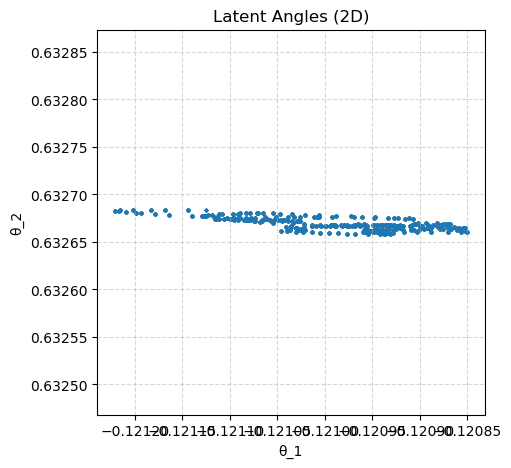

Epoch 12/30, Train Loss: 0.3267, Test Loss: 0.2472
Epoch 12
Step [100/282], Loss: 0.2270, Shape matrix A:1, A_inv_T:1
Step [200/282], Loss: 0.2208, Shape matrix A:1, A_inv_T:1


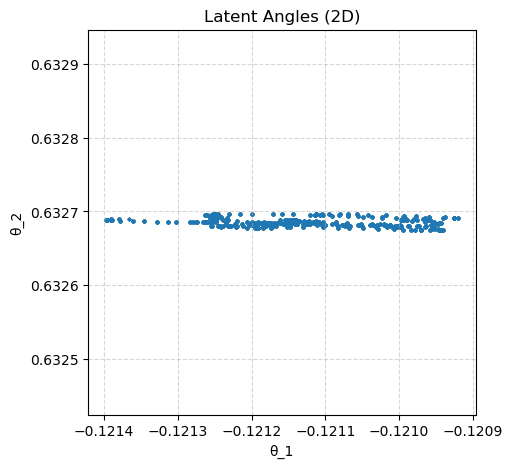

Epoch 13/30, Train Loss: 0.2219, Test Loss: 0.2069
Epoch 13
Step [100/282], Loss: 0.2017, Shape matrix A:1, A_inv_T:1
Step [200/282], Loss: 0.2018, Shape matrix A:1, A_inv_T:1


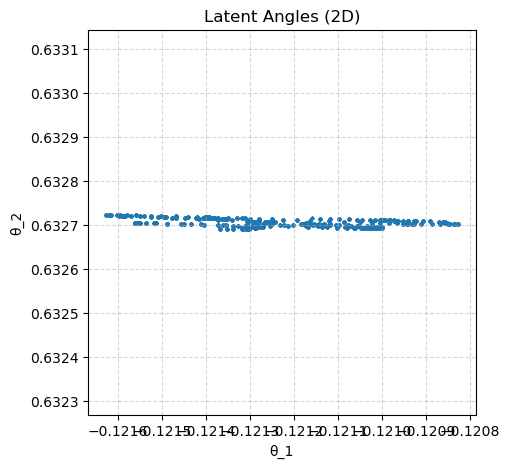

Epoch 14/30, Train Loss: 0.2031, Test Loss: 0.2008
Epoch 14
Step [100/282], Loss: 0.2000, Shape matrix A:1, A_inv_T:1
Step [200/282], Loss: 0.2003, Shape matrix A:1, A_inv_T:1


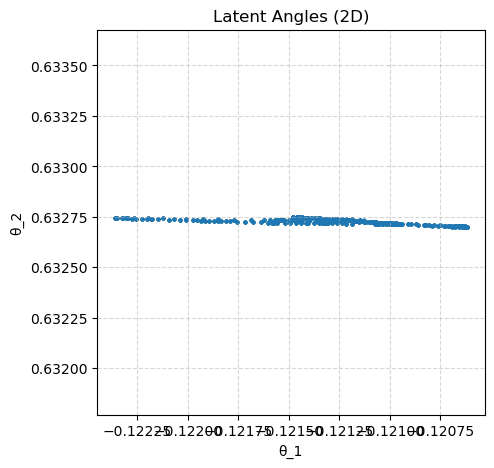

Epoch 15/30, Train Loss: 0.2003, Test Loss: 0.2001
Epoch 15
Step [100/282], Loss: 0.2007, Shape matrix A:1, A_inv_T:1
Step [200/282], Loss: 0.1998, Shape matrix A:1, A_inv_T:1


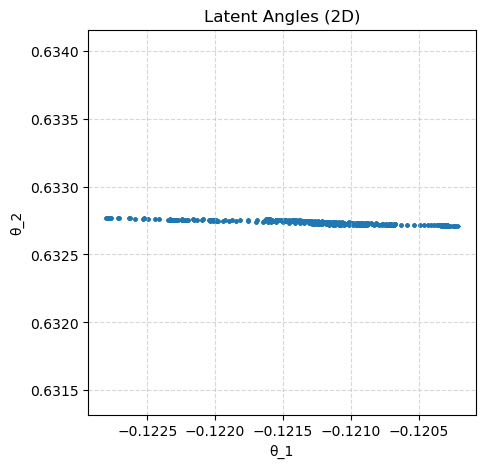

Epoch 16/30, Train Loss: 0.2000, Test Loss: 0.2001
Epoch 16
Step [100/282], Loss: 0.2001, Shape matrix A:1, A_inv_T:1
Step [200/282], Loss: 0.1996, Shape matrix A:1, A_inv_T:1


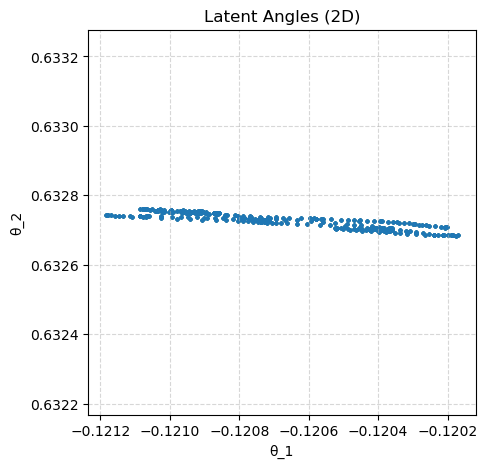

Epoch 17/30, Train Loss: 0.2000, Test Loss: 0.2000
Epoch 17
Step [100/282], Loss: 0.2003, Shape matrix A:1, A_inv_T:1
Step [200/282], Loss: 0.2000, Shape matrix A:1, A_inv_T:1


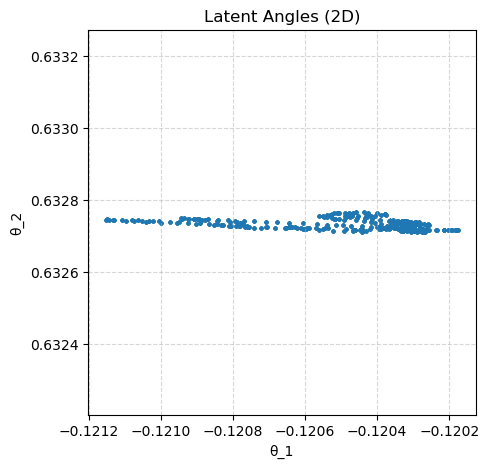

Epoch 18/30, Train Loss: 0.2000, Test Loss: 0.2000
Epoch 18
Step [100/282], Loss: 0.2001, Shape matrix A:1, A_inv_T:1
Step [200/282], Loss: 0.2001, Shape matrix A:1, A_inv_T:1


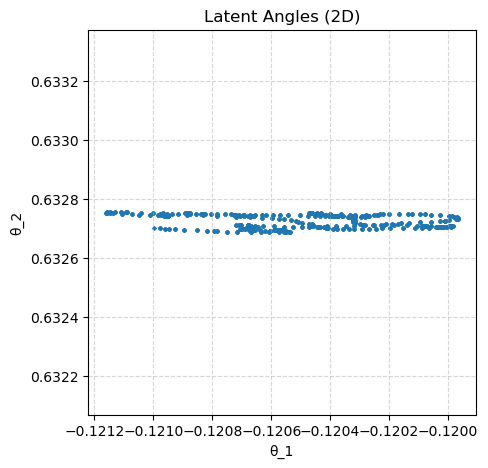

Epoch 19/30, Train Loss: 0.2000, Test Loss: 0.2000
Epoch 19
Step [100/282], Loss: 0.1995, Shape matrix A:1, A_inv_T:1
Step [200/282], Loss: 0.2002, Shape matrix A:1, A_inv_T:1


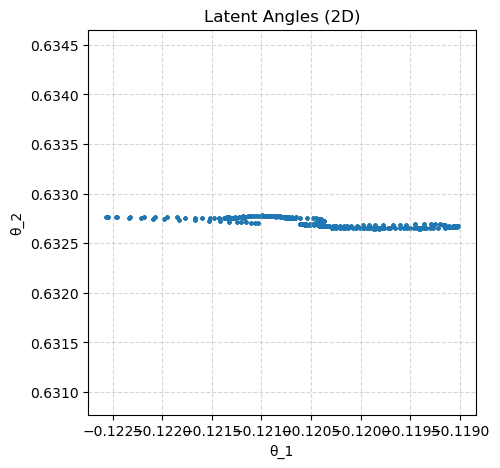

Epoch 20/30, Train Loss: 0.2000, Test Loss: 0.2001
Epoch 20
Step [100/282], Loss: 0.2005, Shape matrix A:1, A_inv_T:1
Step [200/282], Loss: 0.2001, Shape matrix A:1, A_inv_T:1


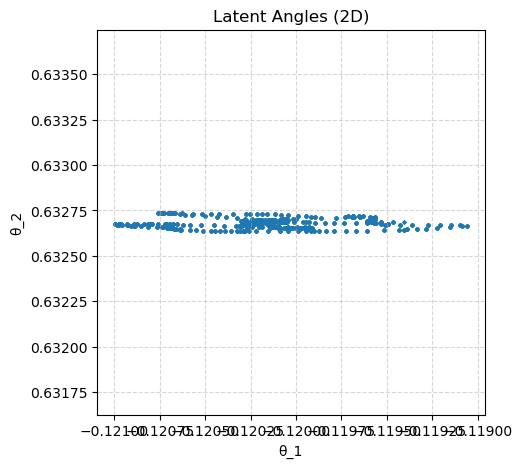

Epoch 21/30, Train Loss: 0.2000, Test Loss: 0.2000
Epoch 21
Step [100/282], Loss: 0.2001, Shape matrix A:1, A_inv_T:1
Step [200/282], Loss: 0.2000, Shape matrix A:1, A_inv_T:1


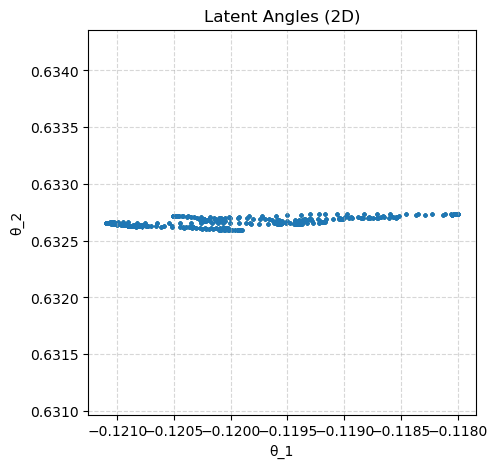

Epoch 22/30, Train Loss: 0.2001, Test Loss: 0.2000
Epoch 22
Step [100/282], Loss: 0.2001, Shape matrix A:1, A_inv_T:1
Step [200/282], Loss: 0.2002, Shape matrix A:1, A_inv_T:1


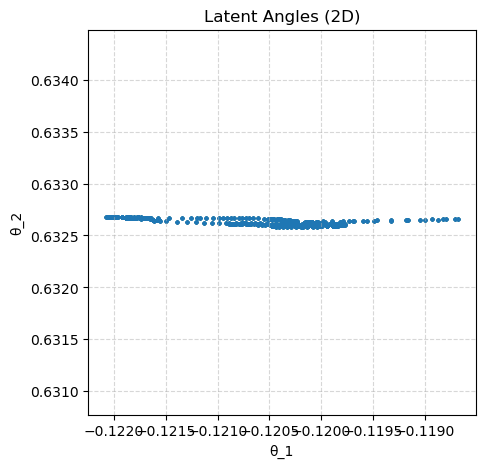

Epoch 23/30, Train Loss: 0.2000, Test Loss: 0.2002
Epoch 23
Step [100/282], Loss: 0.2008, Shape matrix A:1, A_inv_T:1
Step [200/282], Loss: 0.2003, Shape matrix A:1, A_inv_T:1


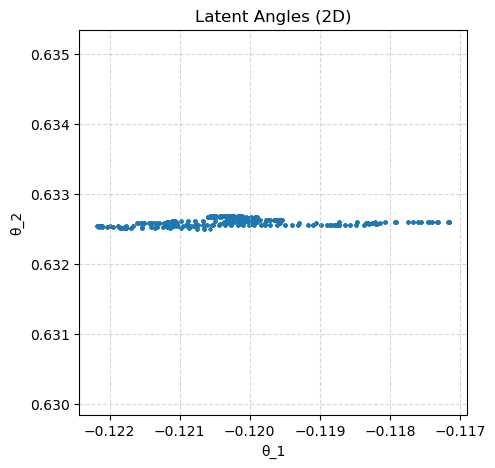

Epoch 24/30, Train Loss: 0.2000, Test Loss: 0.2001
Epoch 24
Step [100/282], Loss: 0.2008, Shape matrix A:1, A_inv_T:1
Step [200/282], Loss: 0.2002, Shape matrix A:1, A_inv_T:1


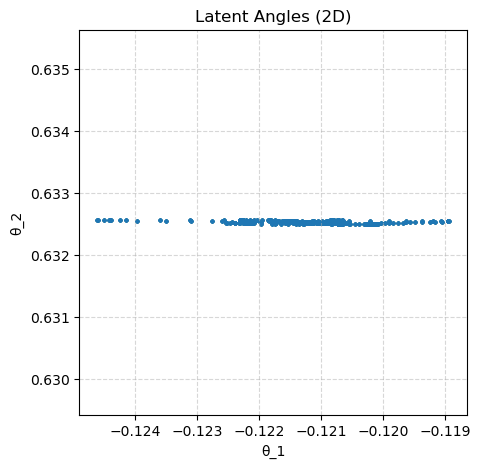

Epoch 25/30, Train Loss: 0.2001, Test Loss: 0.2002
Epoch 25
Step [100/282], Loss: 0.1999, Shape matrix A:1, A_inv_T:1
Step [200/282], Loss: 0.1998, Shape matrix A:1, A_inv_T:1


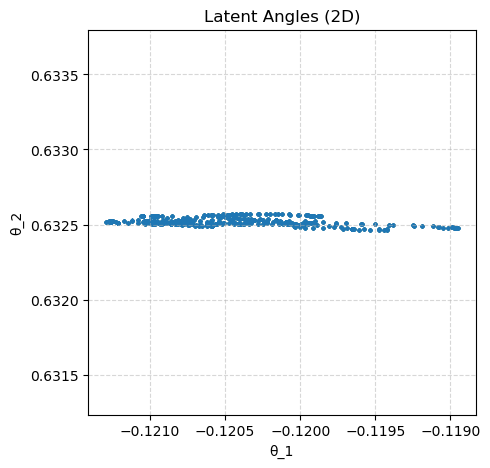

Epoch 26/30, Train Loss: 0.2001, Test Loss: 0.2000
Epoch 26
Step [100/282], Loss: 0.1998, Shape matrix A:1, A_inv_T:1
Step [200/282], Loss: 0.2000, Shape matrix A:1, A_inv_T:1


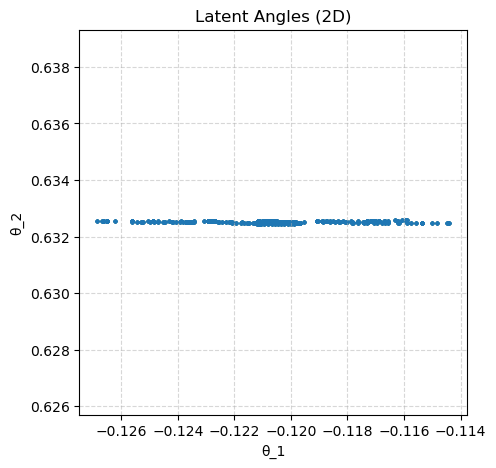

Epoch 27/30, Train Loss: 0.2001, Test Loss: 0.2002
Epoch 27
Step [100/282], Loss: 0.1994, Shape matrix A:1, A_inv_T:1
Step [200/282], Loss: 0.2005, Shape matrix A:1, A_inv_T:1


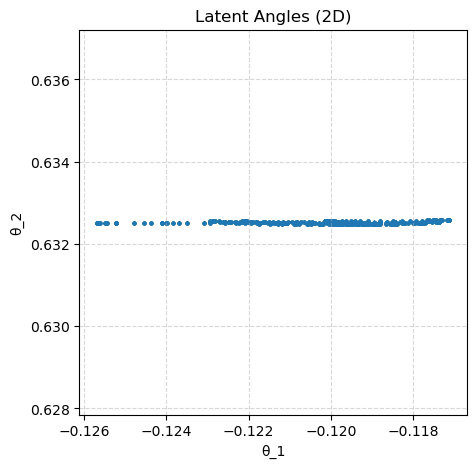

Epoch 28/30, Train Loss: 0.2001, Test Loss: 0.2001
Epoch 28
Step [100/282], Loss: 0.2001, Shape matrix A:1, A_inv_T:1
Step [200/282], Loss: 0.1998, Shape matrix A:1, A_inv_T:1


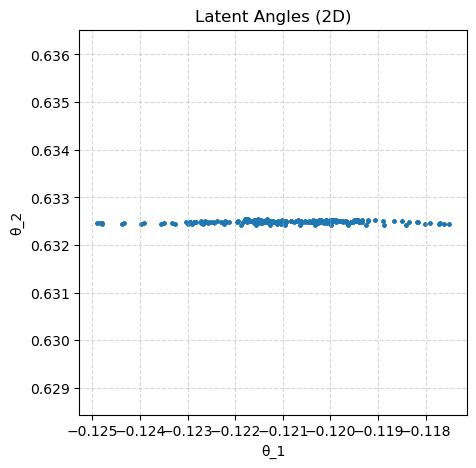

Epoch 29/30, Train Loss: 0.2001, Test Loss: 0.2001
Epoch 29
Step [100/282], Loss: 0.2000, Shape matrix A:1, A_inv_T:1
Step [200/282], Loss: 0.2010, Shape matrix A:1, A_inv_T:1


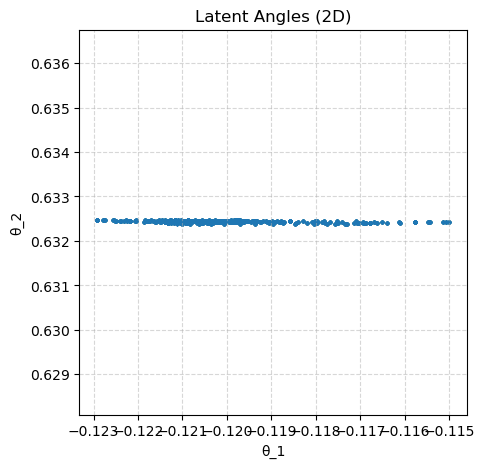

Epoch 30/30, Train Loss: 0.2001, Test Loss: 0.2004


In [21]:
ae_history = AETrainer(shape_model, dataloader, shape_optimizer, trainer_config).train()

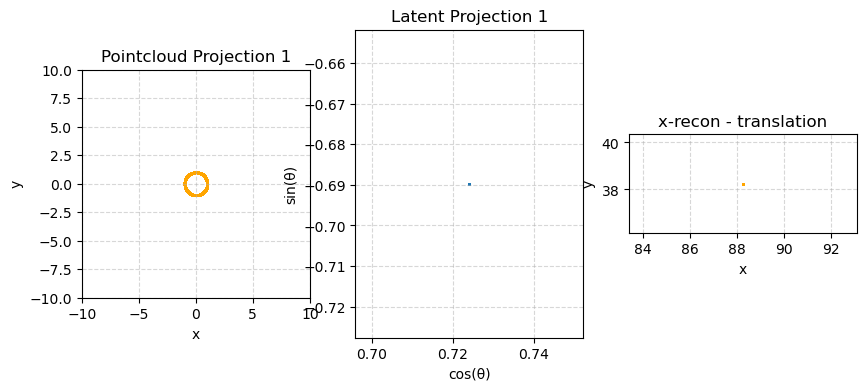

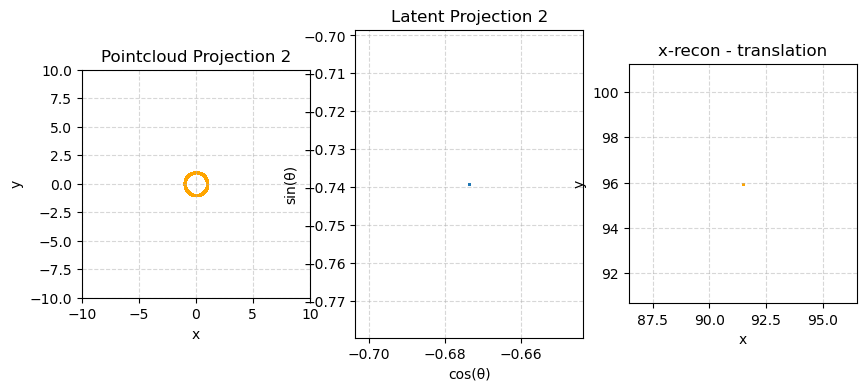

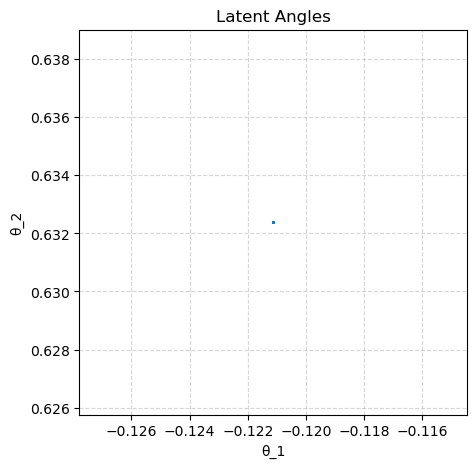

In [28]:
utils.plot_latent_projections(shape_model, pointcloud, train_loader)

### Train and evaluate euclidean model

In [23]:
euclid_ae_history = AETrainer(euclidean_model, dataloader, euclidean_optimizer, trainer_config).train()

Trainer successfully initialized.
Start training...
Epoch 0
Step [100/282], Loss: 2518.7280, Shape matrix A:not defined, A_inv_T:not defined
Step [200/282], Loss: 15.7392, Shape matrix A:not defined, A_inv_T:not defined
Epoch 1/30, Train Loss: 1740.1774, Test Loss: 0.1797
Epoch 1
Step [100/282], Loss: 0.1743, Shape matrix A:not defined, A_inv_T:not defined
Step [200/282], Loss: 0.1756, Shape matrix A:not defined, A_inv_T:not defined
Epoch 2/30, Train Loss: 0.1776, Test Loss: 0.1788
Epoch 2
Step [100/282], Loss: 0.1755, Shape matrix A:not defined, A_inv_T:not defined
Step [200/282], Loss: 0.1813, Shape matrix A:not defined, A_inv_T:not defined
Epoch 3/30, Train Loss: 0.1776, Test Loss: 0.1786
Epoch 3
Step [100/282], Loss: 0.1789, Shape matrix A:not defined, A_inv_T:not defined
Step [200/282], Loss: 0.1695, Shape matrix A:not defined, A_inv_T:not defined
Epoch 4/30, Train Loss: 0.1777, Test Loss: 0.1790
Epoch 4
Step [100/282], Loss: 0.1758, Shape matrix A:not defined, A_inv_T:not defined

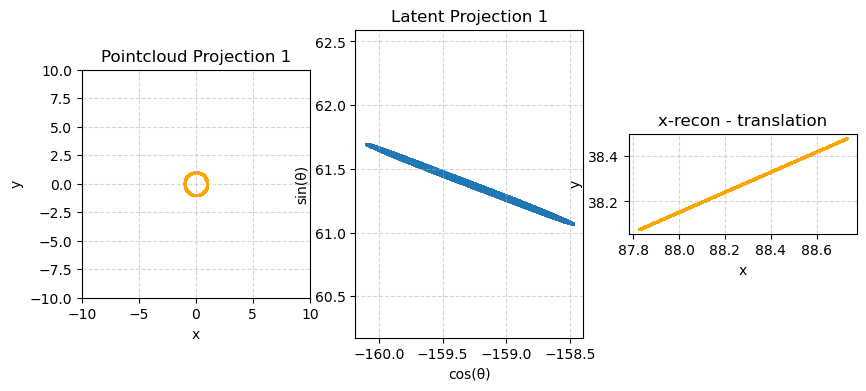

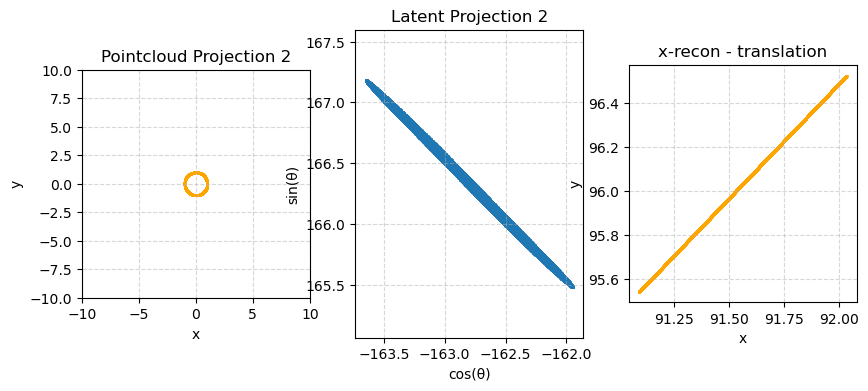

In [27]:
utils.plot_latent_projections(euclidean_model, pointcloud, train_loader)